:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`stochastic_fit.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

# Ignore the specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Stochastic optimization basics

Here we demonstrate how to set up and run stochastic gradient descent in `nemos` -- the standard approach when your dataset does not fit in memory and you need to train the GLM one mini-batch at a time, using each batch to update the model parameters.

Data will be read from disk using [`pynapple`](https://pynapple.org), fed to the GLM's [`stochastic_fit`](nemos.glm.PopulationGLM.stochastic_fit) method with a [`DataLoader`](nemos.batching.DataLoader), and the loss will be logged by a callback.

In [2]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import pynapple as nap
import seaborn as sns

import nemos as nmo
from nemos._documentation_utils._stochastic_optim_toy_data import (
    DEFAULT_NWB_PATH,
    _simulate_and_write_to_disk,
)
from nemos._documentation_utils.plotting import plot_loss_history

jax.config.update("jax_enable_x64", True)
nap.nap_config.suppress_conversion_warnings = True
np.random.seed(123)

Quickly simulate a small example dataset and write it into an [NWB](https://nwb.org) file on disk.

In [3]:
_simulate_and_write_to_disk()

PosixPath('/tmp/stochastic_optim_toy_data.nwb')

## Load data from NWB

Neuroscience data is commonly stored on disk in the [NWB](https://nwb.org) format. `pynapple` provides a convenient way to load data from NWB files:

In [4]:
data = nap.load_file(DEFAULT_NWB_PATH)
data

stochastic_optim_toy_data
┍━━━━━━━━━━━━━━┯━━━━━━━━━━┑
│ Keys         │ Type     │
┝━━━━━━━━━━━━━━┿━━━━━━━━━━┥
│ units        │ TsGroup  │
│ spike_trains │ TsdFrame │
│ X            │ TsdFrame │
┕━━━━━━━━━━━━━━┷━━━━━━━━━━┙

In [5]:
for key in ["units", "spike_trains", "X"]:
    print(f"{key:<15}{data.nwb.objects[data.key_to_id[key]].description}")

units          Spike times of the simulated neurons.
spike_trains   Spike counts binned at 5 ms.
X              Spike trains convolved with a 5D RaisedCosineLogConv basis.200 ms window size.


From these we need the latter two:

`spike_trains` is what we are trying to predict. It holds each neuron's spikes -- whose raw times are in `units` -- already binned at a 5 ms resolution.

Each neuron's spikes will be predicted from the recent spike history of the whole population.
This is precalculated and stored in `X`, which will later act as the model's input variable.

In [6]:
X = data["X"]
spike_trains = data["spike_trains"]

:::{note}
See also: the [convolutional basis](../../background/basis/plot_01_1D_basis_function.md) and [1D convolution](../../background/plot_03_1D_convolution.md) background pages, and the [head-direction tutorial](../../tutorials/plot_02_head_direction.md) for a full worked example of fitting a population GLM on spike history.
:::

## Build the data loader

Data loaders are the standard way of loading data for stochastic optimization. NeMoS ships two built-in loaders that cover most use cases:

- [`ArrayDataLoader`](nemos.batching.ArrayDataLoader): use with in-memory arrays. Input and output are converted to JAX arrays before use. Useful if data fits into memory, but calculations run out of memory, as well as for quick prototyping.
- [`LazyArrayDataLoader`](nemos.batching.LazyArrayDataLoader): use with lazy/out-of-memory arrays, such as dask, zarr, HDF5 (used by NWB).

Here, even though our data would fit into memory, we pretend that it doesn't for illustration purposes.
\
NWB uses HDF5 as a backend and by default `pynapple` loads arrays lazily, meaning that the actual data of `X` and `spike_trains` is not yet loaded into memory.

A closer look at them shows that they are wrapping HDF5 datasets:

In [7]:
print(X.values)
print(spike_trains.values)

<HDF5 dataset "data": shape (10000, 50), type "<f8">
<HDF5 dataset "data": shape (10000, 10), type "<i8">


In this case, we can use `LazyArrayDataLoader` whose main purpose is to allow iterating through the full dataset one batch at a time without loading all the data into memory.

In [8]:
loader = nmo.batching.LazyArrayDataLoader(
    X,
    spike_trains,
    batch_size=100,
)

:::{tip}
A potentially useful workflow is quickly prototyping the analysis with `ArrayDataLoader` on a segment of the full data, then switching to `LazyArrayDataLoader` for fitting the full dataset.
:::

:::{tip}
If the data fits into memory, using [`GLM.fit`](nemos.glm.GLM.fit) instead of stochastic optimization will be faster.
:::

:::{note}
In a [later section](./custom_dataloader.md) we show how to build a custom dataloader.
:::

## Callback for logging

To monitor training progress and the optimization's state during the fitting run, NeMoS has a callback system, allowing to execute custom code on the following events:
- beginning and end of training
- before and after each pass over the data
- before and after each batch

One of the callbacks included is [`TestLossLogger`](nemos.callbacks.TestLossLogger) which allows logging the loss -- here the negative log-likelihood -- on some test data.

Since the dataset is small, we will use all of it for loss logging and evaluate at the beginning of training, then after every batch.
\
In practice this would be expensive to do, and you would typically evaluate on a held-out test set every N-th batch or at the end of each pass.

In [9]:
batch_logger = nmo.callbacks.TestLossLogger(
    X,
    spike_trains,
    events={"train_begin", "batch_end"},
)

## Model configuration

The default algorithm for [`PopulationGLM`](nemos.glm.PopulationGLM) is L-BFGS, whose line search and Hessian estimation are incompatible with stochastic batches. For batching we use plain gradient descent with a fixed stepsize instead.

Accordingly, `stochastic_fit` will error unless acceleration and line searches are turned off.
For the `GradientDescent` solver, set `acceleration=False` and provide an explicit `stepsize`:

In [10]:
glm = nmo.glm.PopulationGLM(
    solver_name="GradientDescent",
    regularizer="Ridge",
    regularizer_strength=0.01,
    solver_kwargs={"stepsize": 0.05, "acceleration": False},
)

:::{tip}
Other solvers that can be used for stochastic optimization can be listed with [`nmo.solvers.list_stochastic_solvers()`](nemos.solvers.list_stochastic_solvers).
:::

## Running the optimization

We are ready to start the optimization using the GLM's `stochastic_fit` method.

`stochastic_fit` uses `n_passes` to control the number of passes over the full dataset and does not stop on convergence by default. Unless a callback requests a stop, it will run for the full number of passes.
\
Note that the `max_steps` solver kwarg used in `GLM.fit` is also ignored.

In [11]:
glm.stochastic_fit(loader, n_passes=5, callbacks=batch_logger)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7fc648286e80>
,regularizer,Ridge()
,regularizer_strength,0.01
,fix_params,"(None, ...)"
,solver_name,'GradientDescent'
,solver_kwargs,"{'acceleration': False, 'stepsize': 0.05}"
,fit_intercept,True
,feature_mask,None
Name,Type,Value
aux_,NoneType,None


<Axes: xlabel='Log index (~batch index)', ylabel='Loss value'>

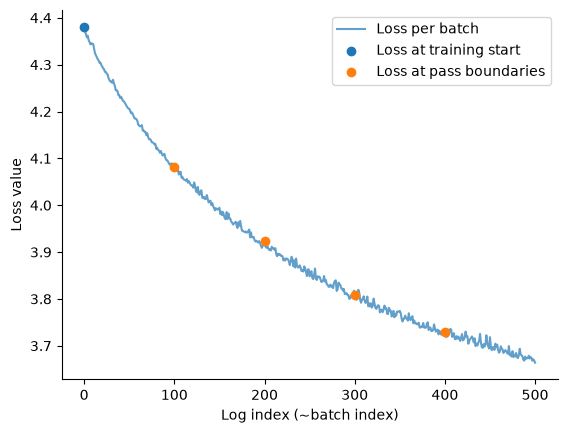

In [12]:
plot_loss_history(batch_logger.loss_history)

The loss is still dropping at the end of the run, so the model hasn't converged yet.

## Continuing fitting

To continue from where we left off, pass the current parameters as `init_params`:

<Axes: xlabel='Log index (~batch index)', ylabel='Loss value'>

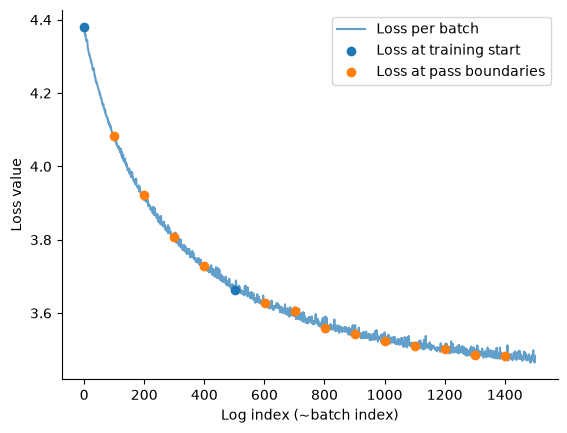

In [13]:
glm.stochastic_fit(
    loader,
    n_passes=10,
    init_params=glm.get_model_params(),
    # using the same callback so the new loss values are appended to the existing history
    callbacks=batch_logger,
)

plot_loss_history(batch_logger.loss_history)

We're getting closer, but still need some training.

:::{tip}
To learn how to stop iteration based on a convergence criterion and how to write a custom callback, see the [](./custom_callbacks_and_termination.md) section.
:::